# 005_backtest - Leader Follower Strategy
## Stage Purpose
This stage evaluates the statistical arbitrage hypotheses identified
in **004_strategy** by constructing and testing trade rules based on
leader–follower shock propagation.

Using the event response structure derived earlier, we simulate
trades that exploit delayed reactions between assets and measure
the resulting performance characteristics.

The goal of this stage is **not discovery**, but **validation**.

---

## Inputs (from 004_strategy)

Loaded from the pipeline manifest:

- `event_response_table.pkl`
  - Event-level response dataset containing:
    - leader coin
    - follower coin
    - t1–t5 response vectors
    - cumulative responses (t1sum, t3sum, t5sum)

- `leader_follower_summary.pkl`
  - Pair-level summary statistics:
    - observation counts
    - mean response metrics
    - propagation indicators

These artifacts represent the **frozen output of the strategy discovery stage**.

---

## Core Tasks

This notebook performs the following steps:

1. **Signal Construction**
   - Define trade triggers based on leader shocks
   - Evaluate follower response expectations

2. **Trade Rule Definition**
   - Entry windows (e.g. t1 or t2)
   - Exit windows (e.g. t3 or t5)
   - Optional filters (signal strength, observation counts)

3. **Trade Simulation**
   - Compute entry and exit returns
   - Aggregate event-level trades into a trade series

4. **Performance Evaluation**
   - cumulative return
   - win rate
   - Sharpe ratio
   - drawdown characteristics

---

## Outputs (Persisted in `output/005_backtest/`)

Artifacts produced by this stage:

- `trade_signals.pkl`
- `trade_results.pkl`
- `equity_curve.pkl`

These outputs are registered in the **pipeline manifest** and serve as
inputs for subsequent evaluation and reporting stages.

---

## Notes

This stage operates exclusively on artifacts generated in
**004_strategy**, ensuring that strategy discovery and validation
remain cleanly separated within the pipeline.

All experiments in this notebook should be reproducible given the
saved artifacts and manifest entries.

## Design Principle

This stage follows several design principles to ensure reproducibility and clarity:

- **Deterministic pipeline** — signals are generated only from artifacts created in earlier stages.
- **Separation of concerns** — strategy construction is separated from backtesting logic.
- **Transparent signal construction** — each step from event detection to portfolio position is explicit.
- **Artifact persistence** — outputs are saved for inspection and reuse.

This structure keeps the strategy layer modular and reproducible within the overall 


### 1. Imports and Environment Setup
### Provide the necessary imports required for to to proceed.   

In [13]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, UTC
import math
from pathlib import Path
import matplotlib.pyplot as plt

### 2. Prepare the environment for the notebook

In [14]:
startdate = "2023-01-01"
trading_days = 252
frequency = "1d"

universe = [
    "BTCUSDT",   # Bitcoin
    "ETHUSDT",   # Ethereum
    "BNBUSDT",   # Binance Coin
    "SOLUSDT",   # Solana
    "XRPUSDT",   # Ripple
    "ADAUSDT",   # Cardano
    "DOGEUSDT",  # Dogecoin
    "AVAXUSDT",  # Avalanche
    "LTCUSDT"    # Litecoin
]

execution_delay = [0, 1, 2, 3]
execution_cost_bps = [20, 30, 40]

stage_label = "005_backtest"

OUTPUT_ROOT = Path("../output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MANIFEST_FILE = OUTPUT_ROOT / "manifest.pkl"

DOWNLOAD_DIR = OUTPUT_ROOT / "001_download"
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

ENRICH_DIR = OUTPUT_ROOT / "002_enrich"
ENRICH_DIR.mkdir(parents=True, exist_ok=True)

ANALYSIS_DIR = OUTPUT_ROOT / "003_analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGY_DIR = OUTPUT_ROOT / "004_strategy"
STRATEGY_DIR.mkdir(parents=True, exist_ok=True)

BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

inspection_window = 20

sigma_threshold = 3

observation_window_length = 10
observation_window = range(1, observation_window_length + 1)

holding_period = 1


### 2.1 Loading the manifest pickle file

In [15]:
if MANIFEST_FILE.exists():
    manifest = pd.read_pickle(MANIFEST_FILE)
else:
    manifest = {}

manifest.setdefault(stage_label, {})

{}

In [16]:
print(manifest)

{'001_download': {'prices': '../output/001_download/PRICES.pkl', 'BTCUSDT': '../output/001_download/BTCUSDT.event_panel.pkl', 'ETHUSDT': '../output/001_download/ETHUSDT.event_panel.pkl', 'BNBUSDT': '../output/001_download/BNBUSDT.event_panel.pkl', 'SOLUSDT': '../output/001_download/SOLUSDT.event_panel.pkl', 'XRPUSDT': '../output/001_download/XRPUSDT.event_panel.pkl', 'ADAUSDT': '../output/001_download/ADAUSDT.event_panel.pkl', 'DOGEUSDT': '../output/001_download/DOGEUSDT.event_panel.pkl', 'AVAXUSDT': '../output/001_download/AVAXUSDT.event_panel.pkl', 'LTCUSDT': '../output/001_download/LTCUSDT.event_panel.pkl'}, '002_enrich': {'events': '../output/002_enrich/events.pkl', 'price_wide': '../output/002_enrich/price_wide.pkl', 'returns_full': '../output/002_enrich/returns_full.pkl', 'rolling_sigma': '../output/002_enrich/rolling_sigma.pkl', 'z_scores': '../output/002_enrich/z_scores.pkl'}, '003_analysis': {'sigma_event_matrix': '../output/003_analysis/sigma_event_matrix.pkl', 'extreme_z_sco

### 3. Load the pickle files from the previous stage
We use these file contents for our analysis.

In [17]:
from pathlib import Path

strategy_dir = Path("../output/004_strategy").resolve()

print("Files in 004_strategy:")
for f in strategy_dir.iterdir():
    print(" -", f.name)

Files in 004_strategy:
 - leader_follower_summary.pkl
 - event_response_table.pkl


In [18]:
event_response_table = pd.read_pickle(STRATEGY_DIR / "event_response_table.pkl")
### event_response_vectors = pd.read_pickle(STRATEGY_DIR / "event_response_vectors.pkl")
leader_follower_summary = pd.read_pickle(STRATEGY_DIR / "leader_follower_summary.pkl")
### response_matrix = pd.read_pickle(STRATEGY_DIR / "response_matrix.pkl")
### sigma_class = pd.read_pickle(STRATEGY_DIR / "sigma_class.pkl")
### strategy_rules = pd.read_pickle(STRATEGY_DIR / "strategy_rules.pkl")

print("event_response_table:", event_response_table.shape)
### print("event_response_vectors:", event_response_vectors.shape)
print("leader_follower_summary:", leader_follower_summary.shape)
### print("response_matrix:", response_matrix.shape)
### print("sigma_class:", sigma_class.shape)
### print("strategy_rules:", strategy_rules.shape)

display(event_response_table.head())

event_response_table: (3, 15)
leader_follower_summary: (3, 6)


,event_date,r_coin,r_sigma,t_coin,t_sigma,act,t_vector,t1,t2,t3,t4,t5,t1sum,t3sum,t5sum
0,2023-08-17 00:00:00+00:00,ADAUSDT,-3,AVAXUSDT,-3,,"[0.025, -0.002, 0.006, -0.048, -0.019]",0.025,-0.002,0.006,-0.048,-0.019,0.025,0.029,-0.038
1,2023-08-17 00:00:00+00:00,LTCUSDT,-3,ETHUSDT,-4,,"[-0.012, 0.005, 0.009, -0.011, -0.02]",-0.012,0.005,0.009,-0.011,-0.020,-0.012,0.002,-0.029
2,2023-10-01 00:00:00+00:00,SOLUSDT,3,AVAXUSDT,2,,"[-0.04, 0.009, 0.07, 0.009, 0.046]",-0.040,0.009,0.070,0.009,0.046,-0.040,0.039,0.094


### 4. Build the Trade log from the event dataframe

In [19]:
trades = []

for _, row in event_response_table.iterrows():

    event_date = row["event_date"]
    leader = row["r_coin"]
    follower = row["t_coin"]

    leader_sigma = row["r_sigma"]
    target_vector = row["t_vector"]

    # trade direction = same sign as leader shock
    direction = 1 if leader_sigma > 0 else -1

    # skip if vector too short
    if len(target_vector) < max(execution_delay) + holding_period:
        continue

    for delay in execution_delay:

        entry_idx = delay
        exit_idx = delay + holding_period

        entry_return = target_vector[entry_idx]
        exit_return = target_vector[exit_idx]

        gross_pnl = direction * (exit_return - entry_return)

        for cost in execution_cost_bps:

            net_pnl = gross_pnl - (cost / 10000)

            trades.append({
                "event_date": event_date,
                "leader": leader,
                "follower": follower,
                "direction": direction,
                "delay": delay,
                "cost_bps": cost,
                "entry_return": entry_return,
                "exit_return": exit_return,
                "gross_pnl": gross_pnl,
                "net_pnl": net_pnl
            })

trade_df = pd.DataFrame(trades)

print("Total trades:", len(trade_df))
display(trade_df.head(3000))

Total trades: 36


,event_date,leader,follower,direction,delay,cost_bps,entry_return,exit_return,gross_pnl,net_pnl
0,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,20,0.025,-0.002,0.027,0.025
1,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,30,0.025,-0.002,0.027,0.024
2,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,40,0.025,-0.002,0.027,0.023
3,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,20,-0.002,0.006,-0.008,-0.010
4,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,30,-0.002,0.006,-0.008,-0.011
5,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,40,-0.002,0.006,-0.008,-0.012
6,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,2,20,0.006,-0.048,0.054,0.052
7,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,2,30,0.006,-0.048,0.054,0.051
8,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,2,40,0.006,-0.048,0.054,0.050
9,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,3,20,-0.048,-0.019,-0.029,-0.031


### 5. Confirm shape of the scenarios

In [20]:
trade_df.groupby(["delay","cost_bps"]).size()

delay  cost_bps
0      20          3
       30          3
       40          3
1      20          3
       30          3
       40          3
2      20          3
       30          3
       40          3
3      20          3
       30          3
       40          3
dtype: int64

### 6. Build Strategy Performance by delay and cost

In [21]:
summary = (
    trade_df
    .groupby(["delay","cost_bps"])["net_pnl"]
    .agg(
        trades="count",
        mean_return="mean",
        std_return="std",
        win_rate=lambda x: (x > 0).mean()
    )
)
summary["sharpe"] = (summary["mean_return"] / summary["std_return"]) * (trading_days ** 0.5)
summary

trades  mean_return  std_return  win_rate    sharpe
delay cost_bps                                                     
0     20             3     0.017667    0.033606  0.666667  8.345336
      30             3     0.016667    0.033606  0.666667  7.872958
      40             3     0.015667    0.033606  0.666667  7.400581
1     20             3     0.014333    0.038734  0.333333  5.874266
      30             3     0.013333    0.038734  0.333333  5.464433
      40             3     0.012333    0.038734  0.333333  5.054601
2     20             3     0.002333    0.059079  0.666667  0.626965
      30             3     0.001333    0.059079  0.666667  0.358266
      40             3     0.000333    0.059079  0.666667  0.089566
3     20             3     0.003667    0.033126  0.666667  1.757124
      30             3     0.002667    0.033126  0.666667  1.277908
      40             3     0.001667    0.033126  0.666667  0.798693

In [22]:
trade_df["gross_pnl"].describe()

count    36.00000
mean      0.01150
std       0.03581
min      -0.06100
25%      -0.01025
50%       0.01450
75%       0.04000
max       0.06100
Name: gross_pnl, dtype: float64

In [23]:
trade_df.groupby("delay")["net_pnl"].mean()

delay
0    0.016667
1    0.013333
2    0.001333
3    0.002667
Name: net_pnl, dtype: float64

In [24]:
trade_df.groupby("delay")["net_pnl"].std()

delay
0    0.029116
1    0.033556
2    0.051171
3    0.028701
Name: net_pnl, dtype: float64

In [25]:
daily = trade_df.groupby("event_date")["net_pnl"].mean()
daily.mean() / daily.std() * np.sqrt(trading_days)

np.float64(16.46329250180534)

In [26]:
delay2 = trade_df[trade_df["delay"] == 2]
daily = delay2.groupby("event_date")["net_pnl"].mean()

daily.mean() / daily.std() * np.sqrt(trading_days)

np.float64(-3.436215967445457)

In [27]:
trade_df.groupby("follower")["net_pnl"].mean().sort_values()

follower
ETHUSDT    -0.00100
AVAXUSDT    0.01325
Name: net_pnl, dtype: float64

In [28]:
split_date = "2025-01-01"

train = trade_df[trade_df["event_date"] < split_date]
test  = trade_df[trade_df["event_date"] >= split_date]

def sharpe(df):
    daily = df.groupby("event_date")["net_pnl"].mean()
    return daily.mean() / daily.std() * np.sqrt(trading_days)

print("TRAIN Sharpe:", sharpe(train))
print("TEST  Sharpe:", sharpe(test))

TRAIN Sharpe: 16.46329250180534
TEST  Sharpe: nan


In [29]:

random_df = trade_df.copy()

coins = trade_df["leader"].unique()

random_df["leader"] = np.random.choice(coins, size=len(random_df))

daily = random_df.groupby("event_date")["net_pnl"].mean()

random_sharpe = daily.mean() / daily.std() * np.sqrt(trading_days)

print("Randomized Leader Sharpe:", random_sharpe)

Randomized Leader Sharpe: 16.46329250180534


In [30]:
print(trade_df.columns)

Index(['event_date', 'leader', 'follower', 'direction', 'delay', 'cost_bps',
       'entry_return', 'exit_return', 'gross_pnl', 'net_pnl'],
      dtype='object')


In [31]:
corr = trade_df["entry_return"].corr(trade_df["exit_return"])
print("Entry/Exit correlation:", corr)

Entry/Exit correlation: 0.1870168828138985


In [32]:
delay2 = trade_df[trade_df["delay"] == 2]

corr = delay2["entry_return"].corr(delay2["exit_return"])

print("Delay=2 entry/exit correlation:", corr)

Delay=2 entry/exit correlation: 0.7945237358825042


In [33]:
trade_df.groupby("delay")["entry_return"].mean()

delay
0   -0.009000
1    0.004000
2    0.028333
3   -0.016667
Name: entry_return, dtype: float64

In [34]:
trade_df.groupby("delay")["exit_return"].mean()

delay
0    0.004000
1    0.028333
2   -0.016667
3    0.002333
Name: exit_return, dtype: float64

Average move by delay:
delay
0    0.013000
1    0.024333
2   -0.045000
3    0.019000
Name: move, dtype: float64


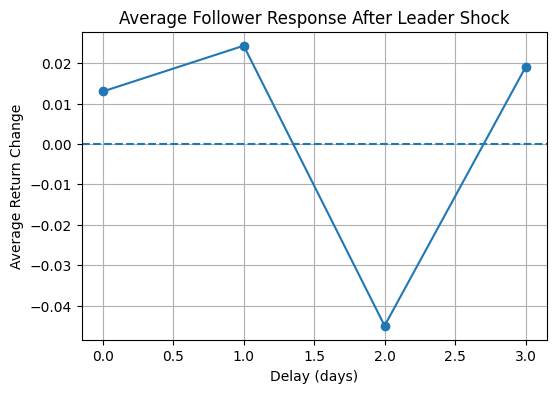

In [35]:
trade_df["move"] = trade_df["exit_return"] - trade_df["entry_return"]

delay_curve = trade_df.groupby("delay")["move"].mean()

print("Average move by delay:")
print(delay_curve)

plt.figure(figsize=(6,4))
plt.plot(delay_curve.index, delay_curve.values, marker="o")

plt.axhline(0, linestyle="--")
plt.title("Average Follower Response After Leader Shock")
plt.xlabel("Delay (days)")
plt.ylabel("Average Return Change")

plt.grid(True)
plt.show()

In [36]:
dip_trades = trade_df[trade_df["delay"] == 1].copy()

# Trade return: buy at overshoot, exit next period
dip_trades["strategy_return"] = -(dip_trades["exit_return"] - dip_trades["entry_return"])

# Apply trading cost
dip_trades["strategy_net"] = dip_trades["strategy_return"] - dip_trades["cost_bps"] / 10000

print("Number of trades:", len(dip_trades))

daily = dip_trades.groupby("event_date")["strategy_net"].mean()

print("\nDaily mean return:", daily.mean())
print("Daily std:", daily.std())

sharpe = daily.mean() / daily.std() * np.sqrt(trading_days)

print("\nDip strategy Sharpe:", sharpe)

print("\nTrade return distribution:")
print(dip_trades["strategy_net"].describe())

Number of trades: 9

Daily mean return: -0.0365
Daily std: 0.038890872965260115

Dip strategy Sharpe: -14.898599412790784

Trade return distribution:
count    9.000000
mean    -0.027333
std      0.027568
min     -0.065000
25%     -0.063000
50%     -0.011000
75%     -0.008000
max     -0.006000
Name: strategy_net, dtype: float64


In [37]:
print(trade_df.columns)
trade_df.head()

Index(['event_date', 'leader', 'follower', 'direction', 'delay', 'cost_bps',
       'entry_return', 'exit_return', 'gross_pnl', 'net_pnl', 'move'],
      dtype='object')


,event_date,leader,follower,direction,delay,cost_bps,entry_return,exit_return,gross_pnl,net_pnl,move
0,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,20,0.025,-0.002,0.027,0.025,-0.027
1,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,30,0.025,-0.002,0.027,0.024,-0.027
2,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,0,40,0.025,-0.002,0.027,0.023,-0.027
3,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,20,-0.002,0.006,-0.008,-0.010,0.008
4,2023-08-17 00:00:00+00:00,ADAUSDT,AVAXUSDT,-1,1,30,-0.002,0.006,-0.008,-0.011,0.008


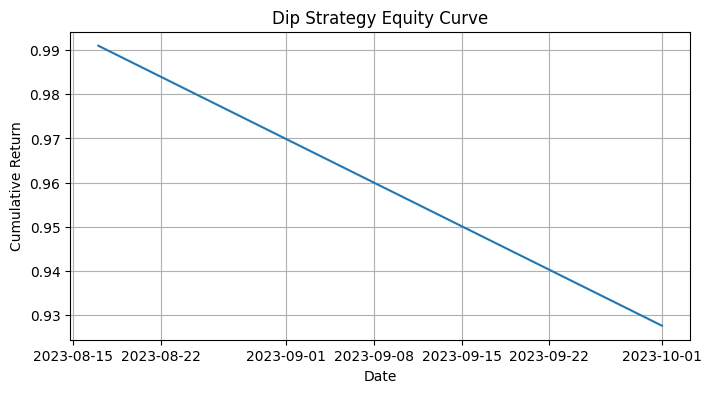

In [38]:
equity_curve = (1 + daily).cumprod()

plt.figure(figsize=(8,4))
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Dip Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

In [39]:
delay_curve = trade_df.groupby("delay")["move"].mean()
print(delay_curve)

delay
0    0.013000
1    0.024333
2   -0.045000
3    0.019000
Name: move, dtype: float64


In [40]:
pair_response = (
    dip_trades
    .groupby(["leader", "follower"])["strategy_net"]
    .agg(["mean", "count"])
    .reset_index()
)

# Only keep pairs with enough observations
pair_response = pair_response[pair_response["count"] >= 10]

pair_response.head(40)

,leader,follower,mean,count


In [41]:
summary_rows = []

for cost, df in trade_df.groupby("cost_bps"):

    daily_returns = df.groupby("event_date")["net_pnl"].mean().sort_index()
    equity_curve = (1 + daily_returns).cumprod()

    total_return = equity_curve.iloc[-1] - 1
    volatility = daily_returns.std() * np.sqrt(trading_days)

    sharpe = (
        daily_returns.mean() /
        daily_returns.std()
    ) * np.sqrt(trading_days)

    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()

    summary_rows.append({
        "cost_bps": cost,
        "total_return": total_return,
        "volatility": volatility,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "trade_count": len(df)
    })

stress_summary = pd.DataFrame(summary_rows).sort_values("cost_bps")

stress_summary

,cost_bps,total_return,volatility,sharpe,max_drawdown,trade_count
0,20,0.024088,0.168375,17.959955,0.0,12
1,30,0.022065,0.168375,16.463293,0.0,12
2,40,0.020044,0.168375,14.966630,0.0,12


### 999. Calculate the remaining and persist to output

In [42]:
BACKTEST_DIR = OUTPUT_ROOT / "005_backtest"
BACKTEST_DIR.mkdir(parents=True, exist_ok=True)

daily_returns = trade_df.groupby("event_date")["net_pnl"].mean()
daily_returns = daily_returns.sort_index()

equity_curve = (1 + daily_returns).cumprod()

total_return = equity_curve.iloc[-1] - 1
volatility = daily_returns.std() * np.sqrt(trading_days)

sharpe = (
    daily_returns.mean() /
    daily_returns.std()
) * np.sqrt(trading_days)

drawdown = equity_curve / equity_curve.cummax() - 1
max_drawdown = drawdown.min()

performance_summary = pd.Series({
    "total_return": total_return,
    "volatility": volatility,
    "sharpe": sharpe,
    "max_drawdown": max_drawdown,
    "avg_trade": trade_df["net_pnl"].mean(),
    "trade_count": len(trade_df)
})

trade_df.to_pickle(BACKTEST_DIR / "trades.pkl")
daily_returns.to_pickle(BACKTEST_DIR / "daily_returns.pkl")
equity_curve.to_pickle(BACKTEST_DIR / "equity_curve.pkl")
performance_summary.to_pickle(BACKTEST_DIR / "performance_summary.pkl")

stress_summary.to_pickle(BACKTEST_DIR / "stress_summary.pkl")
stress_summary.to_csv(BACKTEST_DIR / "stress_summary.csv", index=False)

print("Saved artifacts to:", BACKTEST_DIR)
print()

print("Combined performance:")
print(performance_summary)
print()

print("Cost stress results:")
print(stress_summary)

Saved artifacts to: ../output/005_backtest

Combined performance:
total_return     0.022065
volatility       0.168375
sharpe          16.463293
max_drawdown     0.000000
avg_trade        0.008500
trade_count     36.000000
dtype: float64

Cost stress results:
   cost_bps  total_return  volatility     sharpe  max_drawdown  trade_count
0        20      0.024088    0.168375  17.959955           0.0           12
1        30      0.022065    0.168375  16.463293           0.0           12
2        40      0.020044    0.168375  14.966630           0.0           12
